# Heatmaps: kernel vs. Kernel H2

Carga matrices desde `data/kernel` y `data/kernel_h2`. Para cada combinación muestra el kernel ideal, el Kernel H2 y la diferencia **H2 − ideal**.

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="notebook")

## Combinaciones explícitas

Agregue a la lista solamente las combinaciones que quiera comparar.

In [10]:
COMBINACIONES = [
    {"N": 8, "dim": 2, "featuremap": "efficient_su2"},
]


def encontrar_raiz_repo():
    actual = Path.cwd().resolve()
    for candidato in (actual, *actual.parents):
        if (candidato / "data" / "kernel").is_dir():
            return candidato
    raise FileNotFoundError("No se encontró la raíz del repositorio.")


REPO_ROOT = encontrar_raiz_repo()
KERNEL_DIR = REPO_ROOT / "data" / "kernel"
KERNEL_H2_DIR = REPO_ROOT / "data" / "kernel_h2"
pd.DataFrame(COMBINACIONES)

,N,dim,featuremap
0,8,2,efficient_su2


## Carga de matrices

In [11]:
def cargar_matriz(ruta):
    datos = pd.read_csv(ruta)
    if datos.columns[0].startswith("Unnamed"):
        datos = datos.iloc[:, 1:]
    matriz = datos.to_numpy(dtype=float)
    if matriz.shape[0] != matriz.shape[1]:
        raise ValueError(f"La matriz {ruta.name} no es cuadrada: {matriz.shape}")
    if not np.isfinite(matriz).all():
        raise ValueError(f"La matriz {ruta.name} contiene NaN o infinitos.")
    return matriz


def obtener_rutas(combinacion):
    nombre = (
        f"n_{combinacion['N']}_dim_{combinacion['dim']}_"
        f"{combinacion['featuremap']}.csv"
    )
    return KERNEL_DIR / nombre, KERNEL_H2_DIR / nombre

## Heatmaps

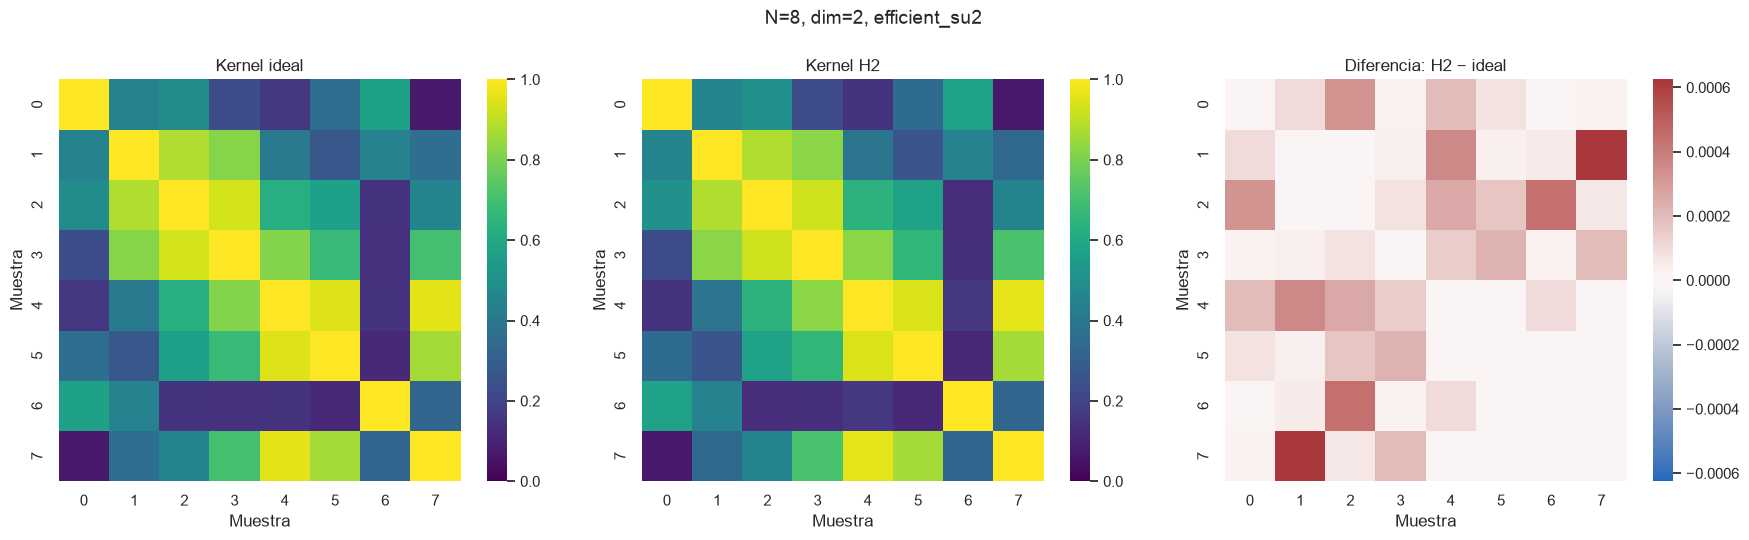

,N,dim,featuremap,forma,diferencia_media_absoluta,diferencia_maxima_absoluta
0,8,2,efficient_su2,"(8, 8)",0.0001,0.0006


In [12]:
resumen = []

for combinacion in COMBINACIONES:
    ruta_kernel, ruta_h2 = obtener_rutas(combinacion)
    titulo = (
        f"N={combinacion['N']}, dim={combinacion['dim']}, "
        f"{combinacion['featuremap']}"
    )

    faltantes = [ruta for ruta in (ruta_kernel, ruta_h2) if not ruta.exists()]
    if faltantes:
        print(f"No se puede comparar {titulo}:")
        for ruta in faltantes:
            print(f"  Falta {ruta}")
        continue

    kernel = cargar_matriz(ruta_kernel)
    kernel_h2 = cargar_matriz(ruta_h2)

    if kernel.shape != kernel_h2.shape:
        print(f"Formas incompatibles para {titulo}: {kernel.shape} y {kernel_h2.shape}")
        continue

    diferencia = (kernel_h2 - kernel)**2
    limite = max(float(np.abs(diferencia).max()), 1e-12)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.heatmap(kernel, cmap="viridis", vmin=0, vmax=1, square=True, ax=axes[0])
    sns.heatmap(kernel_h2, cmap="viridis", vmin=0, vmax=1, square=True, ax=axes[1])
    sns.heatmap(
        diferencia, cmap="vlag", center=0, vmin=-limite, vmax=limite,
        square=True, ax=axes[2]
    )

    axes[0].set_title("Kernel ideal")
    axes[1].set_title("Kernel H2")
    axes[2].set_title("Diferencia: H2 − ideal")
    for eje in axes:
        eje.set_xlabel("Muestra")
        eje.set_ylabel("Muestra")

    fig.suptitle(titulo, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    resumen.append({
        **combinacion,
        "forma": str(kernel.shape),
        "diferencia_media_absoluta": np.abs(diferencia).mean(),
        "diferencia_maxima_absoluta": np.abs(diferencia).max(),
    })

if resumen:
    display(pd.DataFrame(resumen).style.format({
        "diferencia_media_absoluta": "{:.4f}",
        "diferencia_maxima_absoluta": "{:.4f}",
    }))